# 41 — Audio Explainability

Generates attribution visualisations for both fine-tuned audio models
(**wav2vec2-base** and **DistilHuBERT**) using two complementary methods:

| Method | What it shows |
|---|---|
| **Integrated Gradients** (Captum) | Sample-level attribution on the normalised waveform, integrated from a silent baseline |
| **Temporal Occlusion** | Importance of each time window measured by silencing it and monitoring the predicted-class probability drop |

**Depends on:** `02_preprocess_audio.ipynb` (run automatically below).

**Reads checkpoints from:** `../experiments/audio_unimodal/v2/<model_slug>/model/`

**Writes plots to:** `../experiments/explainability/audio/<model_slug>/`

---
*Requires:* `captum>=0.7.0` — install with `pip install captum`


e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\.venv\Lib\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Label map: {'anger': 0, 'disgust': 1, 'fear': 2, 'happiness': 3, 'neutral': 4, 'sadness': 5, 'surprise': 6}
Train: 9,988 | Dev: 1,108 | Test: 2,610
Duration stats (sampled 500 files):
  mean  : 3.23 s
  median: 2.43 s
  max   : 41.05 s
  >MAX_AUDIO_S (10.0s): 14 clips


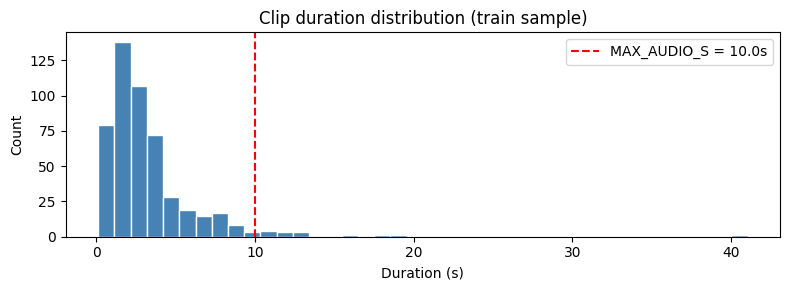

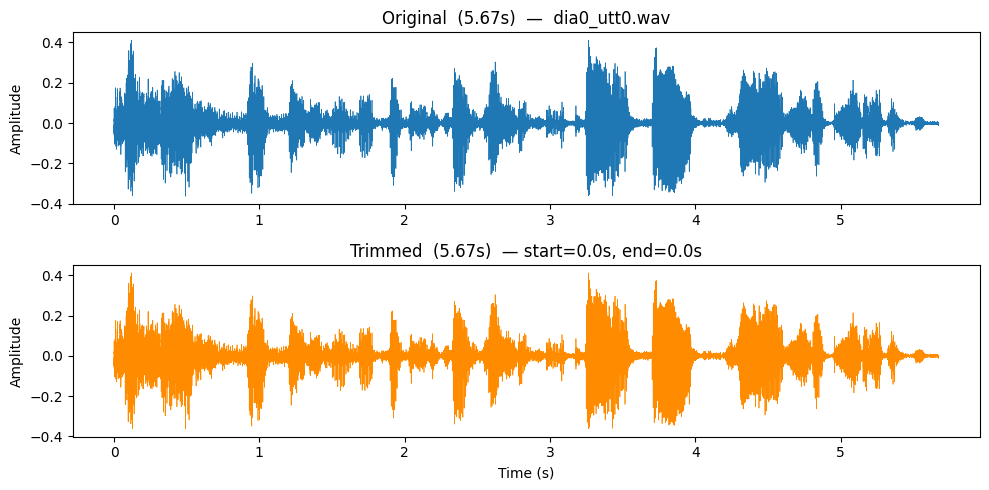

[train] OK — 9,988 rows
[dev] OK — 1,108 rows
[test] OK — 2,610 rows


In [1]:
%run 02_preprocess_audio.ipynb
# Imports: train_df_audio, dev_df_audio, test_df_audio, label2id, id2label, labels_sorted

In [2]:
import os, sys, json
import numpy as np
import torch
import torchaudio
from transformers import AutoModelForAudioClassification, AutoFeatureExtractor

_here = os.path.abspath(os.getcwd())
_root = _here if os.path.isdir(os.path.join(_here, "src")) else os.path.abspath(os.path.join(_here, ".."))
if _root not in sys.path:
    sys.path.insert(0, _root)

from src.config import (
    EXP_ROOT_AUDIO, EXP_ROOT_EXPLAIN, VERSION,
    AUDIO_MODELS_TO_RUN, AUDIO_TEST_DIR, DEVICE, SAMPLE_RATE,
)
from src.training.utils import slugify
from src.explainability import AudioExplainer
from src.explainability.utils import (
    make_explain_dir, select_explanation_samples,
    plot_waveform_attribution, plot_temporal_occlusion,
)

print("Device:", DEVICE)
print("Models:", AUDIO_MODELS_TO_RUN)

Device: cuda
Models: ['facebook/wav2vec2-base', 'ntu-spml/distilhubert']


## Load checkpoints

Trim settings are read from each run's `config.json` to ensure they match
exactly what was used during training (v2 used 0.3 s head/tail trim).


In [3]:
# Audio version with trimming experiments
AUDIO_VERSION = "v2"

def load_audio_model(model_name):
    slug      = slugify(model_name)
    run_dir   = os.path.join(EXP_ROOT_AUDIO, AUDIO_VERSION, slug)
    model_dir = os.path.join(run_dir, "model")
    assert os.path.isdir(model_dir), f"Checkpoint not found: {model_dir}"

    # Read the trim/max_audio settings saved at training time
    cfg         = json.load(open(os.path.join(run_dir, "config.json")))
    trim_start  = cfg.get("trim_start_s", 0.0)
    trim_end    = cfg.get("trim_end_s",   0.0)
    max_audio   = cfg.get("max_audio_s",  10.0)

    model     = AutoModelForAudioClassification.from_pretrained(model_dir).to(DEVICE).eval()
    feat_ext  = AutoFeatureExtractor.from_pretrained(model_dir)
    explainer = AudioExplainer(
        model, feat_ext, DEVICE,
        trim_start_s=trim_start,
        trim_end_s=trim_end,
        max_audio_s=max_audio,
    )
    print(f"  Loaded {model_name}  "
          f"(trim={trim_start}s/{trim_end}s, max={max_audio}s)")
    return explainer

explainers = {}
for mname in AUDIO_MODELS_TO_RUN:
    print(f"Loading {mname} …")
    explainers[mname] = load_audio_model(mname)
print("All models loaded.")

Loading facebook/wav2vec2-base …


Loading weights: 100%|██████████| 215/215 [00:00<00:00, 816.06it/s, Materializing param=wav2vec2.masked_spec_embed]                                            


  Loaded facebook/wav2vec2-base  (trim=0.3s/0.3s, max=10.0s)
Loading ntu-spml/distilhubert …


Loading weights: 100%|██████████| 53/53 [00:00<00:00, 1064.07it/s, Materializing param=projector.weight]                                                    

  Loaded ntu-spml/distilhubert  (trim=0.3s/0.3s, max=10.0s)
All models loaded.


## Collect test-set predictions

Run inference over the full test split for each model and select
representative samples.


In [4]:
from torch.utils.data import DataLoader
from src.data.audio_preprocessing import AudioEmotionDataset, AudioCollator

@torch.no_grad()
def get_audio_test_preds(explainer, test_df, audio_test_dir):
    collator = AudioCollator(explainer.feature_extractor, SAMPLE_RATE)
    dataset  = AudioEmotionDataset(
        test_df, audio_test_dir,
        sample_rate=explainer.sample_rate,
        max_audio_s=explainer.max_samples / explainer.sample_rate,
        trim_start_s=explainer.trim_start / explainer.sample_rate,
        trim_end_s=explainer.trim_end   / explainer.sample_rate,
    )
    loader = DataLoader(dataset, batch_size=8, shuffle=False, collate_fn=collator)
    preds, labels = [], []
    for batch in loader:
        batch  = {k: v.to(DEVICE) for k, v in batch.items()}
        logits = explainer.model(input_values=batch["input_values"]).logits
        preds.extend(logits.argmax(dim=-1).cpu().tolist())
        labels.extend(batch["labels"].cpu().tolist())
    return preds, labels

model_samples = {}
for mname, explainer in explainers.items():
    print(f"Inference: {mname} …")
    preds, labels = get_audio_test_preds(explainer, test_df_audio, AUDIO_TEST_DIR)
    acc = sum(p == l for p, l in zip(preds, labels)) / len(labels)
    print(f"  Accuracy: {acc:.4f}")
    samples = select_explanation_samples(labels, preds, id2label, n_correct=1, n_incorrect=1)
    model_samples[mname] = {"preds": preds, "labels": labels, "samples": samples}
    print(f"  Selected {sum(len(v) for v in samples.values())} samples")

Inference: facebook/wav2vec2-base …
  Accuracy: 0.4513
  Selected 12 samples
Inference: ntu-spml/distilhubert …
  Accuracy: 0.4303
  Selected 12 samples


## Generate explanations

For each model and each selected sample:
- **IG plot**: waveform + per-sample attribution heatmap (50 steps)
- **Temporal Occlusion plot**: probability-drop bar chart (20 segments)


In [7]:
IG_STEPS    = 50
N_SEGMENTS  = 20
MIN_AUDIO_S = 0.5  # Skip samples shorter than this

filenames = test_df_audio["filename"].tolist()

for mname, explainer in explainers.items():
    slug    = slugify(mname)
    out_dir = make_explain_dir("audio", slug)
    samples = model_samples[mname]["samples"]
    labels  = model_samples[mname]["labels"]
    preds   = model_samples[mname]["preds"]

    print(f"\n=== {mname} → {out_dir} ===")
    for emotion, sample_list in samples.items():
        for idx, is_correct in sample_list:
            fname        = filenames[idx]
            wav_path     = os.path.join(AUDIO_TEST_DIR, fname)
            true_label   = id2label[labels[idx]]
            pred_label   = id2label[preds[idx]]
            correctness  = "correct" if is_correct else "wrong"
            sample_tag   = f"{emotion.lower()}_{correctness}_idx{idx}"

            # Load raw waveform
            waveform, sr = torchaudio.load(wav_path)
            if sr != SAMPLE_RATE:
                waveform = torchaudio.functional.resample(waveform, sr, SAMPLE_RATE)
            if waveform.shape[0] > 1:
                waveform = waveform.mean(dim=0, keepdim=True)
            waveform_np = waveform.squeeze(0).numpy().astype(np.float32)

            duration_s = explainer.preprocess(waveform_np).numel() / SAMPLE_RATE
            
            # Skip samples that are too short
            if duration_s < MIN_AUDIO_S:
                print(f"  [{emotion}] {'✓' if is_correct else '✗'}  {fname}  ({duration_s:.2f}s) — SKIPPED (too short)")
                continue
            
            print(f"  [{emotion}] {'✓' if is_correct else '✗'}  {fname}  ({duration_s:.2f}s)")

            # ── Integrated Gradients ────────────────────────────────────────
            attr, input_proc, pred_cls = explainer.integrated_gradients(
                waveform_np, n_steps=IG_STEPS
            )
            title_ig = (
                f"IG  |  {mname.split('/')[-1]}  |  "
                f"True: {true_label}  Pred: {pred_label}"
            )
            plot_waveform_attribution(
                input_proc, attr, SAMPLE_RATE, title_ig,
                save_path=os.path.join(out_dir, f"ig_{sample_tag}.png"),
            )

            # ── Temporal Occlusion ──────────────────────────────────────────
            scores, input_proc2, _ = explainer.temporal_occlusion(
                waveform_np, n_segments=N_SEGMENTS, target_class=pred_cls
            )
            dur = len(input_proc2) / SAMPLE_RATE
            title_occ = (
                f"Temporal Occlusion  |  {mname.split('/')[-1]}  |  "
                f"True: {true_label}  Pred: {pred_label}"
            )
            plot_temporal_occlusion(
                scores, dur, title_occ,
                save_path=os.path.join(out_dir, f"occ_{sample_tag}.png"),
            )

    print(f"  Saved to {out_dir}")

print("\nDone — all audio explanations saved.")


=== facebook/wav2vec2-base → ../experiments/explainability\audio\facebook_wav2vec2_base ===
  [anger] ✓  dia164_utt7.wav  (2.05s)
  [anger] ✗  dia192_utt4.wav  (0.91s)
  [disgust] ✗  dia278_utt0.wav  (3.03s)
  [fear] ✗  dia50_utt2.wav  (1.75s)
  [happiness] ✓  dia132_utt4.wav  (2.11s)
  [happiness] ✗  dia139_utt4.wav  (0.00s) — SKIPPED (too short)
  [neutral] ✓  dia202_utt0.wav  (0.45s) — SKIPPED (too short)
  [neutral] ✗  dia143_utt1.wav  (6.38s)
  [sadness] ✓  dia174_utt6.wav  (2.75s)
  [sadness] ✗  dia199_utt13.wav  (4.90s)
  [surprise] ✓  dia22_utt19.wav  (0.74s)
  [surprise] ✗  dia182_utt8.wav  (2.07s)
  Saved to ../experiments/explainability\audio\facebook_wav2vec2_base

=== ntu-spml/distilhubert → ../experiments/explainability\audio\ntu_spml_distilhubert ===
  [anger] ✓  dia169_utt22.wav  (2.32s)
  [anger] ✗  dia204_utt9.wav  (7.55s)
  [disgust] ✗  dia17_utt4.wav  (1.09s)
  [fear] ✗  dia50_utt2.wav  (1.75s)
  [happiness] ✓  dia161_utt4.wav  (1.49s)
  [happiness] ✗  dia74_utt0.w

## Quick sanity check

Display the first IG figure inline.


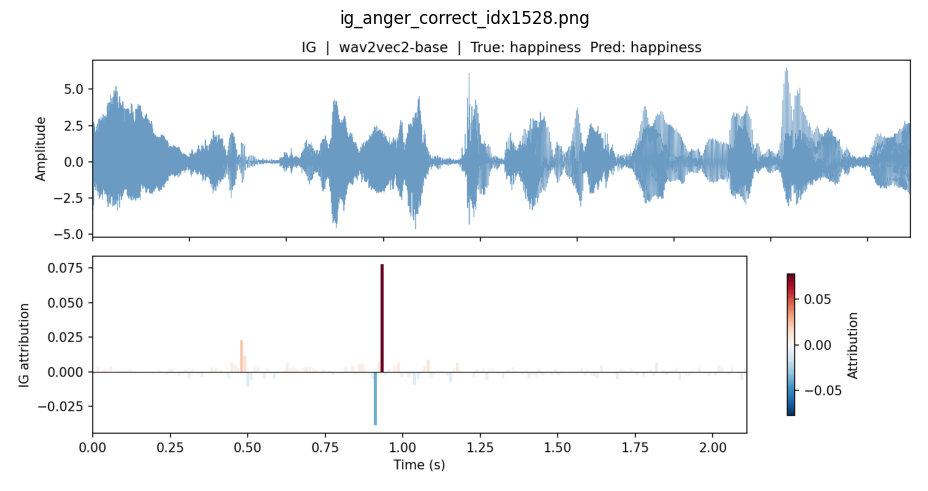

: 

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

for mname in AUDIO_MODELS_TO_RUN:
    slug    = slugify(mname)
    out_dir = os.path.join(EXP_ROOT_EXPLAIN, "audio", slug)
    pngs    = sorted([f for f in os.listdir(out_dir) if f.startswith("ig_")])
    if pngs:
        img = mpimg.imread(os.path.join(out_dir, pngs[4]))
        plt.figure(figsize=(10, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.title(pngs[0])
        plt.tight_layout()
        plt.show()
        break